## Baseline Erf Model

### NB
This cell needs to be run two times because of a package conflict: ood_metrics requires an older numpy
version than the one of colab. Thus, we need to restart the session and run the cell again.

In [4]:
# @title
!pip install ood_metrics
!pip install lightning > /dev/null
!pip install gitignore_parser > /dev/null
!pip install -U 'jsonargparse[signatures]>=4.27.7' >/dev/null

In [5]:
# @title
from google.colab import drive
import os
import sys
import json
import yaml
import torch
import importlib
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from lightning import seed_everything

# 1. Mount Drive and Configure Paths
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

project_root = '/content/drive/MyDrive/FundGitHubProject'
if not os.path.exists('/content/ProjectFolder'):
  # creates shortcut to access the project folder
  !ln -s /content/drive/MyDrive/FundGitHubProject /content/ProjectFolder
eomt_folder = project_root + '/eomt'

os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if eomt_folder not in sys.path:
    sys.path.insert(0, eomt_folder)

from eval.iouEval import iouEval
seed_everything(0, verbose=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Active Device: cuda


In [6]:
import torch

erfnet_pretrained = torch.load('trained_models/erfnet_encoder_pretrained.pth.tar')

In [7]:
import torch
import os
from eomt.datasets.cityscapes_semantic import CityscapesSemantic

# Import the model class (usually named Net or ERFNet in standard implementations)
try:
    from eval.erfnet import Net as ERFNet
except ImportError:
    from eval.erfnet import ERFNet

# Provide the path to the Cityscapes dataset
dataset_path = os.path.join(project_root, 'eomt/data') # adjust this path as needed

# Instantiate the DataModule (it needs self)
cityscapes_dm = CityscapesSemantic(path=dataset_path)

# Lightning DataModules typically require setup before getting dataloaders
cityscapes_dm.setup(stage='validate')
val_dataloader = cityscapes_dm.val_dataloader()

# Remove 'module.' prefix from state dict keys (caused by DataParallel)
# Check if the loaded content is a dictionary and contains 'state_dict'
if isinstance(erfnet_pretrained, dict) and 'state_dict' in erfnet_pretrained:
    state_dict_to_clean = erfnet_pretrained['state_dict']
else:
    state_dict_to_clean = erfnet_pretrained

# Remove both 'module.' and 'features.' prefixes
cleaned_state_dict = {}
for k, v in state_dict_to_clean.items():
    new_k = k.replace('module.', '')
    new_k = new_k.replace('features.', '')
    cleaned_state_dict[new_k] = v

# Initialize the model (Cityscapes typically has 19 or 20 classes)
try:
    model = ERFNet(19)
    # Try to load with strict=False in case there are missing keys (e.g., decoder)
    model.load_state_dict(cleaned_state_dict, strict=False)
except RuntimeError:
    # Fallback to 20 classes if state_dict shapes mismatch
    model = ERFNet(20)
    model.load_state_dict(cleaned_state_dict, strict=False)

# Move model to device and set to evaluation mode
model = model.to(device)
model.eval()

for batch_idx, batch in enumerate(val_dataloader):
    # Lightning dataloaders usually return (images, targets)
    images, targets = batch
    if isinstance(images, tuple):
        images = torch.stack(images)

    # Cast to float to match model weights, scaling to [0, 1]
    images = images.to(device).float() / 255.0

    # Forward pass without calculating gradients
    with torch.no_grad():
        outputs = model(images)

    print(f"Successfully processed batch {batch_idx}! Output shape: {outputs.shape}")
    break


Successfully processed batch 0! Output shape: torch.Size([16, 19, 1024, 2048])


## ERFNet Anomaly Detection Baseline

In [8]:
print("Running evalAnomaly.py via CLI...")
!cd {project_root}/eval && python evalAnomaly.py \
    --input "Validation_Dataset/RoadAnomaly/images/*.jpg" \
    --loadDir "../trained_models/" \
    --loadWeights "erfnet_pretrained.pth" \
    --loadModel "erfnet.py" | grep -v "images/"

Running evalAnomaly.py via CLI...
Loading model: ../trained_models/erfnet.py
Loading weights: ../trained_models/erfnet_pretrained.pth
Model and weights LOADED successfully
AUPRC score: 15.581983299743523
FPR@TPR95: 73.24763926329555


In [9]:
print("Running evalAnomaly.py via CLI...")
!cd {project_root}/eval && python evalAnomaly.py \
    --input "Validation_Dataset/RoadAnomaly21/images/*.png" \
    --loadDir "../trained_models/" \
    --loadWeights "erfnet_pretrained.pth" \
    --loadModel "erfnet.py" | grep -v "images/"

Running evalAnomaly.py via CLI...
Loading model: ../trained_models/erfnet.py
Loading weights: ../trained_models/erfnet_pretrained.pth
Model and weights LOADED successfully
AUPRC score: 38.319578121119356
FPR@TPR95: 59.33706864897953


In [10]:
import os

eval_script = os.path.join(project_root, 'eval', 'evalAnomaly.py')
with open(eval_script, 'r') as f:
    content = f.read()

# Patch the script to replace .webp with .png for ground truth masks
content = content.replace('.replace("images", "labels_masks")', '.replace("images", "labels_masks").replace(".webp", ".png")')
content = content.replace(".replace('images', 'labels_masks')", ".replace('images', 'labels_masks').replace('.webp', '.png')")

with open(eval_script, 'w') as f:
    f.write(content)

print("Running evalAnomaly.py via CLI...")
!cd {project_root}/eval && python evalAnomaly.py \
    --input "Validation_Dataset/RoadObstacle21/images/*.webp" \
    --loadDir "../trained_models/" \
    --loadWeights "erfnet_pretrained.pth" \
    --loadModel "erfnet.py" | grep -v "images/"

Running evalAnomaly.py via CLI...
Loading model: ../trained_models/erfnet.py
Loading weights: ../trained_models/erfnet_pretrained.pth
Model and weights LOADED successfully
AUPRC score: 4.6265677513628045
FPR@TPR95: 48.443441222061765


In [11]:
import os

# Patch 1: Fix .jpg to .png replacement for ground truth masks
content = content.replace('.replace("images", "labels_masks")', '.replace("images", "labels_masks").replace(".jpg", ".png")')
content = content.replace(".replace('images', 'labels_masks')", ".replace('images', 'labels_masks').replace('.jpg', '.png')")

with open(eval_script, 'w') as f:
    f.write(content)

print("Running evalAnomaly.py via CLI...")
!cd {project_root}/eval && python evalAnomaly.py \
    --input "Validation_Dataset/fs_static/images/*.jpg" \
    --loadDir "../trained_models/" \
    --loadWeights "erfnet_pretrained.pth" \
    --loadModel "erfnet.py" | grep -v "images/"

Running evalAnomaly.py via CLI...
Loading model: ../trained_models/erfnet.py
Loading weights: ../trained_models/erfnet_pretrained.pth
Model and weights LOADED successfully
AUPRC score: 9.498677681348113
FPR@TPR95: 40.300119503862554


Loading model weights from /content/drive/MyDrive/FundGitHubProject/trained_models/erfnet_pretrained.pth
Visualizing image: /content/drive/MyDrive/FundGitHubProject/eval/Validation_Dataset/RoadAnomaly21/images/9.png


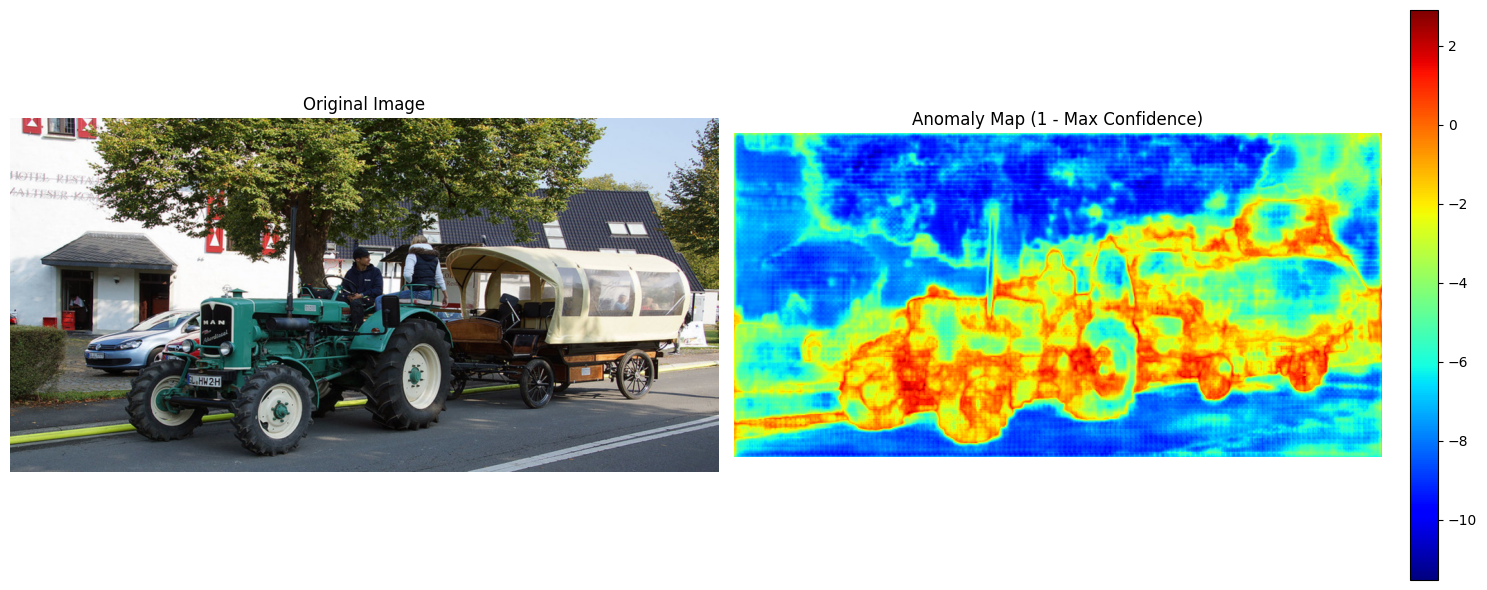

In [13]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor

# Import ERFNet correctly depending on how it's defined in the repo
try:
    from eval.erfnet import Net as ERFNet
except ImportError:
    from eval.erfnet import ERFNet

# 1. Setup Model and Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ERFNet(20) # 20 classes used in the evaluation script

weightspath = os.path.join(project_root, 'trained_models', 'erfnet_pretrained.pth')
print(f"Loading model weights from {weightspath}")

# Custom loading to handle 'module.' prefixes if saved from DataParallel
state_dict = torch.load(weightspath, map_location=device)
own_state = model.state_dict()
for name, param in state_dict.items():
    if name.startswith("module."):
        name = name.split("module.")[-1]
    if name in own_state:
        own_state[name].copy_(param)
    else:
        print(f"Skipping {name}")

model = model.to(device)
model.eval()

# 2. Get a sample image
# Use recursive search to find the images regardless of where Validation_Dataset is located
search_pattern = os.path.join(project_root, '**', 'Validation_Dataset', '**', 'images', '*.*')
all_images = glob.glob(search_pattern, recursive=True)
sample_images = [f for f in all_images if f.endswith(('.jpg', '.png', '.webp'))]

if not sample_images:
    print("No images found. Please verify the dataset path.")
else:
    image_path = sample_images[0] # Take the first image
    print(f"Visualizing image: {image_path}")

    # 3. Transform the Image
    input_transform = Compose([
        Resize((512, 1024), Image.BILINEAR),
        ToTensor(),
    ])

    img_pil = Image.open(image_path).convert('RGB')
    img_tensor = input_transform(img_pil).unsqueeze(0).to(device)

    # 4. Predict and compute anomaly score
    with torch.no_grad():
        output = model(img_tensor)

    # The baseline anomaly score is 1.0 - max_class_confidence
    anomaly_map = 1.0 - np.max(output.squeeze(0).cpu().numpy(), axis=0)

    # 5. Visualize
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot Original
    axes[0].imshow(img_pil.resize((1024, 512)))
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Plot Anomaly Map
    im = axes[1].imshow(anomaly_map, cmap='jet')
    axes[1].set_title("Anomaly Map (1 - Max Confidence)")
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()